# CC219 – Aplicaciones de Data Science (2026-2)
## Hito 1 (Trabajo Parcial): Triage Inteligente y Normalización de Reseñas Móviles

**Integrantes:**
- Alarcón Castellanos, Ericks Santiago
- Austin Bryan Flores Burga
- Diego Alejandro Flores Mamani

**Sección:** CC92  
**Objetivo:** Implementar la ingesta, exploración de variables (EDA), normalización y preprocesamiento de lenguaje natural (NLP) sobre el corpus de reseñas de aplicaciones móviles para la preparación de los modelos predictivos del Hito 2.

In [3]:
# Configuración inicial de librerías y entorno
import os
import re
from collections import Counter
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

### 1. Carga e Inspección de Datos
Lectura del conjunto de datos original `multilingual_mobile_app_reviews_2025.csv` y filtrado de registros incompletos.

In [4]:
# Carga del dataset original
df = pd.read_csv('multilingual_mobile_app_reviews_2025.csv')
print("Dimensiones iniciales del dataset:", df.shape)

# Depuración de valores nulos en el cuerpo de texto y calificación
df_clean = df.dropna(subset=['review_text', 'rating']).copy()
print("Dimensiones tras depurar valores nulos:", df_clean.shape)

# Resumen estadístico del rating
df_clean[['rating', 'num_helpful_votes', 'user_age']].describe()

Dimensiones iniciales del dataset: (2514, 15)
Dimensiones tras depurar valores nulos: (2418, 15)


,rating,num_helpful_votes,user_age
count,2418.000000,2418.000000,2418.000000
mean,3.018569,616.357320,44.240695
std,1.150513,364.117225,18.354708
min,1.000000,0.000000,13.000000
25%,2.000000,286.000000,28.000000
50%,3.000000,618.500000,44.000000
75%,4.000000,919.750000,60.000000
max,5.000000,1249.000000,75.000000


### 2. Análisis Exploratorio de Datos (EDA)
Visualización de la distribución de calificaciones (*ratings*) y concentración de reseñas por aplicación móvil.

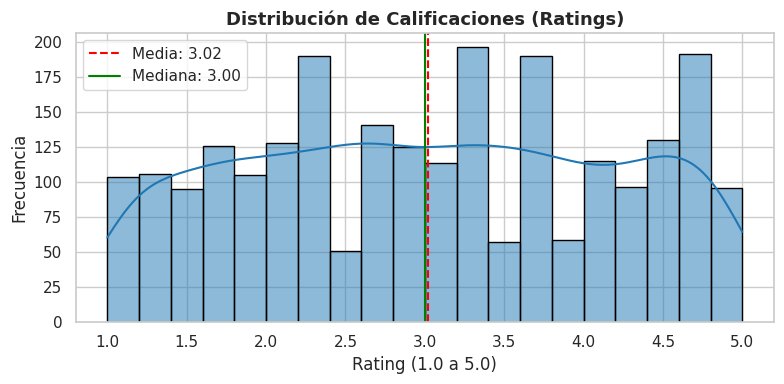

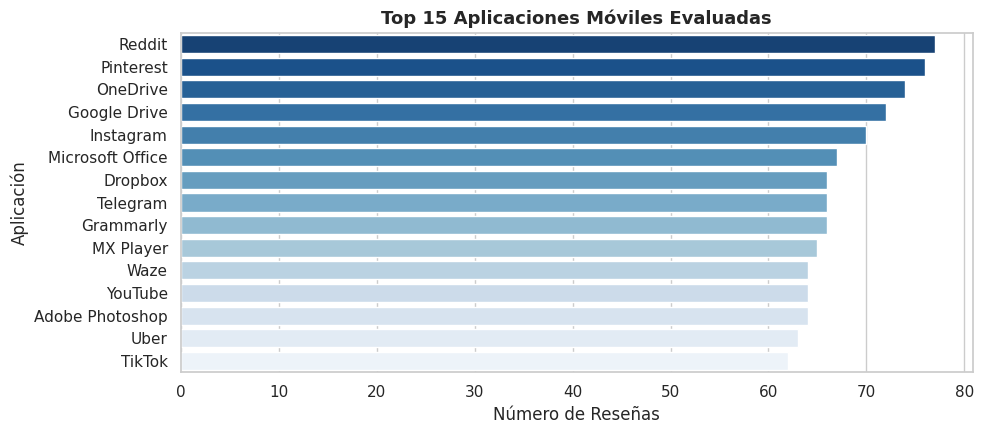

In [5]:
# Directorio para figuras exportadas
os.makedirs('eda_figures', exist_ok=True)

# 2.1 Distribución de Ratings
plt.figure(figsize=(8, 4))
sns.histplot(
    df_clean['rating'],
    bins=20,
    kde=True,
    color='#1f77b4',
    edgecolor='black',
)
plt.title('Distribución de Calificaciones (Ratings)', fontsize=13, fontweight='bold')
plt.xlabel('Rating (1.0 a 5.0)')
plt.ylabel('Frecuencia')
plt.axvline(df_clean['rating'].mean(), color='red', linestyle='--', label=f'Media: {df_clean["rating"].mean():.2f}')
plt.axvline(df_clean['rating'].median(), color='green', linestyle='-', label=f'Mediana: {df_clean["rating"].median():.2f}')
plt.legend()
plt.tight_layout()
plt.savefig('eda_figures/fig1_ratings.png', dpi=300)
plt.show()

# 2.2 Top 15 Aplicaciones Móviles con Mayor Volumen de Reseñas
plt.figure(figsize=(10, 4.5))
top_apps = df_clean['app_name'].value_counts().head(15)
sns.barplot(x=top_apps.values, y=top_apps.index, hue=top_apps.index, palette='Blues_r', legend=False)
plt.title('Top 15 Aplicaciones Móviles Evaluadas', fontsize=13, fontweight='bold')
plt.xlabel('Número de Reseñas')
plt.ylabel('Aplicación')
plt.tight_layout()
plt.savefig('eda_figures/fig2_top_apps.png', dpi=300)
plt.show()

### 3. Pipeline de Limpieza y Normalización NLP
Sanitización del texto con expresiones regulares (minúsculas, eliminación de URLs y signos) y remoción de *stopwords*.

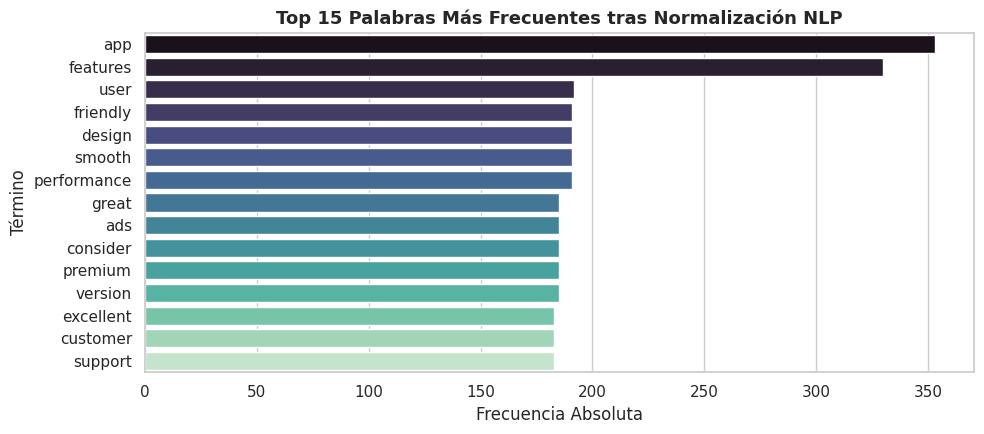

In [6]:
def normalize_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    tokens = text.split()
    clean_tokens = [w for w in tokens if w not in ENGLISH_STOP_WORDS and len(w) > 2]
    return ' '.join(clean_tokens)

# Aplicación de la normalización sobre el texto no estructurado
df_clean['cleaned_text'] = df_clean['review_text'].apply(normalize_text)

# Análisis de frecuencia de términos clave
all_words = ' '.join(df_clean['cleaned_text']).split()
freq_words = Counter(all_words).most_common(15)
words, counts = zip(*freq_words)

# Gráfico de términos más frecuentes
plt.figure(figsize=(10, 4.5))
sns.barplot(x=list(counts), y=list(words), hue=list(words), palette='mako', legend=False)
plt.title('Top 15 Palabras Más Frecuentes tras Normalización NLP', fontsize=13, fontweight='bold')
plt.xlabel('Frecuencia Absoluta')
plt.ylabel('Término')
plt.tight_layout()
plt.savefig('eda_figures/fig3_top_palabras.png', dpi=300)
plt.show()

### 4. Exportación del Dataset Limpio
Persistencia del dataset resultante en `data/reviews_cleaned_nlp.csv` para la posterior fase de modelamiento supervisado y Transformers en el Hito 2.

In [7]:
# Creación de la carpeta data y exportación final
os.makedirs('data', exist_ok=True)
df_clean.to_csv('data/reviews_cleaned_nlp.csv', index=False)
print("✓ Dataset limpio exportado exitosamente en data/reviews_cleaned_nlp.csv")

✓ Dataset limpio exportado exitosamente en data/reviews_cleaned_nlp.csv
